# Parquet Pipeline

In [1]:
%load_ext autoreload
%autoreload 2

import sys, logging, importlib

# Ensure your scripts dir is importable
sys.path.append("/global/cfs/cdirs/m4958/usr/danieltm/ColliderML/software/colliderml_dev/scripts/postprocessing")

# 1) Set global logging and quiet noisy libs
logging.basicConfig(
    level=logging.DEBUG,
    format="%(asctime)s - %(levelname)s - %(name)s - %(message)s",
    force=True,
)
for noisy in ["uproot", "fsspec", "s3fs", "urllib3", "numexpr", "matplotlib"]:
    logging.getLogger(noisy).setLevel(logging.WARNING)

# 2) Turn up only your modules to DEBUG (others inherit WARNING from above)
for name in [
    "convert_all",
    "convert_particles",
    "convert_digihits",
    "convert_tracks",
    "utils",
    "utils.track_utils",
    "utils.driver",
    "utils.path_utils",
]:
    logging.getLogger(name).setLevel(logging.DEBUG)

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import uproot
import sys
import seaborn as sns
from tqdm import tqdm
import networkx as nx
import matplotlib.cm as cm
import h5py
import pyarrow as pa
import pyarrow.parquet as pq
import logging
import awkward as ak
import uproot

import atlasify as atl
from particle import Particle
atl.ATLAS = "ColliderML"

import pyhepmc as hep
from pyhepmc.io import WriterAscii

sys.path.append("/global/cfs/cdirs/m4958/usr/danieltm/ColliderML/software/OtherLibraries/pyedm4hep")
from pyedm4hep import EDM4hepEvent, EDM4hepEventBatch

from pathlib import Path
import logging

# Reuse postprocessing helpers
sys.path.append("/global/cfs/cdirs/m4958/usr/danieltm/ColliderML/software/colliderml_dev/scripts/postprocessing")
from convert_particles import build_particles_df_with_parents_and_vertex, write_particles_with_selection
from convert_digihits import process_event_for_digihits, write_digihits_with_selection
from convert_calorimeter import write_calohits_with_selection
from utils.path_utils import get_run_paths, make_dir
from utils.track_utils import load_root_file, load_track_summary, create_particle_barcode_map

from convert_all import convert_all


2025-10-29 02:56:20,877 - DEBUG - h5py._conv - Creating converter from 7 to 5
2025-10-29 02:56:20,878 - DEBUG - h5py._conv - Creating converter from 5 to 7
2025-10-29 02:56:20,878 - DEBUG - h5py._conv - Creating converter from 7 to 5
2025-10-29 02:56:20,878 - DEBUG - h5py._conv - Creating converter from 5 to 7


### Roadmap

- Load parquet files (tracks, tracker_hits, calo_hits, particles)
- Calculate the run that corresponds to that event
- Load edm4hep file (edm4hep.root), looking just at that event
- Using position and vertex merges, ensure that ALL hits and particles are present in the edm4hep file
- Visualise the event (hits, tracks)
- Deduce the hepmc file and event number from the edm4hep event
- Load the hepmc file and event number in hard scatter AND merged versions
- Ensure that ALL generator particles are present in the hepmc files and vice versa

## Testing parquet outputs

In [3]:
import pandas as pd
import pyarrow.parquet as pq
import numpy as np
import awkward as ak

def load_all_particles_parquet(parquet_path, event_id=None):
    """
    Load particles data from Parquet file using awkward arrays for fast exploding.
    
    Args:
        parquet_path: Path to Parquet file
        event_id: Optional specific event ID to load. If None, loads all events.
    
    Returns:
        DataFrame with particles data (flat format with one row per particle)
    """
    # Read parquet file
    df = pd.read_parquet(parquet_path)
    
    if df.empty:
        return pd.DataFrame()
    
    if event_id is not None:
        # Filter to specific event
        df = df[df['event_id'] == event_id]
        if df.empty:
            return pd.DataFrame()
    
    # Check if data needs exploding by examining first non-event_id column
    non_event_cols = [c for c in df.columns if c != 'event_id']
    if not non_event_cols:
        return df
    
    first_val = df[non_event_cols[0]].iloc[0]
    
    # If it's not a list, data is already flat
    if not isinstance(first_val, (list, np.ndarray)):
        return df
    
    # Use awkward array for fast exploding
    # Convert to awkward array - use ak.from_iter for nested Python lists
    ak_dict = {}
    
    # Convert each column to awkward array
    for col in df.columns:
        if col == 'event_id':
            ak_dict[col] = ak.Array(df[col].tolist())
        else:
            # For nested columns, use tolist() to convert properly
            ak_dict[col] = ak.Array(df[col].tolist())
    
    # Flatten/explode all nested lists
    flat_dict = {}
    
    # For event_id, we need to repeat it based on the length of the nested arrays
    list_lens = ak.num(ak_dict[non_event_cols[0]])
    flat_dict['event_id'] = ak.flatten(ak.broadcast_arrays(ak_dict['event_id'], ak_dict[non_event_cols[0]])[0])
    
    # For list columns, just flatten them
    for col in non_event_cols:
        flat_dict[col] = ak.flatten(ak_dict[col])
    
    # Convert back to pandas
    result = pd.DataFrame({k: ak.to_numpy(v) for k, v in flat_dict.items()})
    return result


def load_all_digihits_parquet(parquet_path, event_id=None):
    """
    Load digihits data from Parquet file using awkward arrays.
    
    Args:
        parquet_path: Path to Parquet file
        event_id: Optional specific event ID to load. If None, loads all events.
    
    Returns:
        DataFrame with digihits data (flat format with one row per hit)
    """
    # Read parquet file
    df = pd.read_parquet(parquet_path)
    
    if df.empty:
        return pd.DataFrame()
    
    if event_id is not None:
        df = df[df['event_id'] == event_id]
        if df.empty:
            return pd.DataFrame()
    
    # Check if data needs exploding
    non_event_cols = [c for c in df.columns if c != 'event_id']
    if not non_event_cols:
        return df
    
    first_val = df[non_event_cols[0]].iloc[0]
    
    if not isinstance(first_val, (list, np.ndarray)):
        return df
    
    # Use awkward for fast exploding
    ak_dict = {}
    for col in df.columns:
        if col == 'event_id':
            ak_dict[col] = ak.Array(df[col].tolist())
        else:
            ak_dict[col] = ak.Array(df[col].tolist())
    
    # Flatten
    flat_dict = {}
    list_lens = ak.num(ak_dict[non_event_cols[0]])
    flat_dict['event_id'] = ak.flatten(ak.broadcast_arrays(ak_dict['event_id'], ak_dict[non_event_cols[0]])[0])
    
    for col in non_event_cols:
        flat_dict[col] = ak.flatten(ak_dict[col])
    
    result = pd.DataFrame({k: ak.to_numpy(v) for k, v in flat_dict.items()})
    return result


def load_all_tracks_parquet(parquet_path, event_id=None):
    """
    Load tracks data from Parquet file using awkward arrays.
    
    Args:
        parquet_path: Path to Parquet file
        event_id: Optional specific event ID to load. If None, loads all events.
    
    Returns:
        Tuple of (tracks_df, hits_df) where hits_df contains track hit associations
    """
    # Read parquet file
    df = pd.read_parquet(parquet_path)
    
    if df.empty:
        return pd.DataFrame(), None
    
    if event_id is not None:
        df = df[df['event_id'] == event_id]
        if df.empty:
            return pd.DataFrame(), None
    
    # Check if data needs exploding
    non_event_cols = [c for c in df.columns if c != 'event_id']
    if not non_event_cols:
        return df, None
    
    first_val = df[non_event_cols[0]].iloc[0]
    
    # If already flat
    if not isinstance(first_val, (list, np.ndarray)):
        if 'hit_ids' in df.columns:
            hits_df = df[['event_id', 'track_id', 'hit_ids']].copy()
            tracks_df = df.drop(columns=['hit_ids'])
            return tracks_df, hits_df
        return df, None
    
    # Use awkward for fast exploding
    has_hit_ids = 'hit_ids' in df.columns
    
    # Separate hit_ids from other columns
    track_cols = [c for c in non_event_cols if c != 'hit_ids']
    
    # Convert to awkward arrays
    ak_dict = {}
    for col in ['event_id'] + track_cols:
        if col == 'event_id':
            ak_dict[col] = ak.Array(df[col].tolist())
        else:
            ak_dict[col] = ak.Array(df[col].tolist())
    
    # Flatten track data
    flat_dict = {}
    if track_cols:
        list_lens = ak.num(ak_dict[track_cols[0]])
        flat_dict['event_id'] = ak.flatten(ak.broadcast_arrays(ak_dict['event_id'], ak_dict[track_cols[0]])[0])
        
        for col in track_cols:
            flat_dict[col] = ak.flatten(ak_dict[col])
    
    tracks_df = pd.DataFrame({k: ak.to_numpy(v) for k, v in flat_dict.items()})
    
    # Handle hit_ids separately if present
    hits_df = None
    if has_hit_ids and 'track_id' in tracks_df.columns:
        # hit_ids is a list of lists - need to keep as lists in the output
        ak_hit_ids = ak.Array(df['hit_ids'].tolist())
        
        # Get track_id and event_id (already flattened)
        flat_hit_dict = {
            'event_id': flat_dict['event_id'],
            'track_id': flat_dict['track_id'],
            'hit_ids': ak.flatten(ak_hit_ids)  # Flatten outer list, keep inner lists
        }
        
        # Convert to pandas, but keep hit_ids as lists
        hits_df = pd.DataFrame({
            'event_id': ak.to_numpy(flat_hit_dict['event_id']),
            'track_id': ak.to_numpy(flat_hit_dict['track_id']),
            'hit_ids': ak.to_list(flat_hit_dict['hit_ids'])  # Keep as Python lists
        })
    
    return tracks_df, hits_df


def load_all_calohits_parquet(parquet_path, event_id=None):
    """
    Load calorimeter hits data from Parquet file using awkward arrays.
    
    Calorimeter data has nested contribution lists (particle IDs, energies, times)
    that are kept as lists in the output, representing multiple particle contributions
    to each cell.
    
    Args:
        parquet_path: Path to Parquet file
        event_id: Optional specific event ID to load. If None, loads all events.
    
    Returns:
        DataFrame with calorimeter hits (flat format with one row per cell, 
        with nested contribution lists preserved)
    """
    # Read parquet file
    df = pd.read_parquet(parquet_path)
    
    if df.empty:
        return pd.DataFrame()
    
    if event_id is not None:
        df = df[df['event_id'] == event_id]
        if df.empty:
            return pd.DataFrame()
    
    # Check if data needs exploding
    non_event_cols = [c for c in df.columns if c != 'event_id']
    if not non_event_cols:
        return df
    
    # Identify contribution columns (nested lists that should be preserved)
    contrib_cols = [c for c in df.columns if c.startswith('contrib_')]
    
    # Get first non-contribution column to check if data needs exploding
    non_contrib_cols = [c for c in non_event_cols if c not in contrib_cols]
    if not non_contrib_cols:
        return df
    
    first_val = df[non_contrib_cols[0]].iloc[0]
    
    # If it's not a list, data is already flat
    if not isinstance(first_val, (list, np.ndarray)):
        return df
    
    # Use awkward for fast exploding
    # Separate scalar columns from contribution columns
    scalar_cols = [c for c in df.columns if c not in contrib_cols]
    
    # Convert scalar columns to awkward arrays
    ak_dict = {}
    for col in scalar_cols:
        if col == 'event_id':
            ak_dict[col] = ak.Array(df[col].tolist())
        else:
            ak_dict[col] = ak.Array(df[col].tolist())
    
    # Flatten scalar columns
    flat_dict = {}
    if non_contrib_cols:
        list_lens = ak.num(ak_dict[non_contrib_cols[0]])
        flat_dict['event_id'] = ak.flatten(ak.broadcast_arrays(ak_dict['event_id'], ak_dict[non_contrib_cols[0]])[0])
        
        for col in non_contrib_cols:
            flat_dict[col] = ak.flatten(ak_dict[col])
    
    # Handle contribution columns separately - flatten outer list but keep inner lists
    for col in contrib_cols:
        if col in df.columns:
            ak_col = ak.Array(df[col].tolist())
            flat_dict[col] = ak.to_list(ak.flatten(ak_col))
    
    # Convert back to pandas
    result = pd.DataFrame(flat_dict)
    return result


In [4]:
global_event_id = 3
chunk_size = 10
chunk_number = global_event_id // chunk_size
event_range = f"events{chunk_number*chunk_size}-{chunk_number*chunk_size+chunk_size-1}"

In [5]:
event_range

'events0-9'

In [6]:
# Update file paths to point to parquet files
particles_file = f"/global/cfs/cdirs/m4958/data/ColliderML/simulation/full_pileup/ttbar/v1/parquet/truth/particles/hard_scatter.ttbar.v1.truth.particles.{event_range}.parquet"
digihits_file = f"/global/cfs/cdirs/m4958/data/ColliderML/simulation/full_pileup/ttbar/v1/parquet/reco/tracker_hits/hard_scatter.ttbar.v1.reco.tracker_hits.{event_range}.parquet"
tracks_file = f"/global/cfs/cdirs/m4958/data/ColliderML/simulation/full_pileup/ttbar/v1/parquet/reco/tracks/hard_scatter.ttbar.v1.reco.tracks.{event_range}.parquet"
calohits_file = f"/global/cfs/cdirs/m4958/data/ColliderML/simulation/full_pileup/ttbar/v1/parquet/reco/calo_hits/hard_scatter.ttbar.v1.reco.calo_hits.{event_range}.parquet"

In [10]:
# Update file paths to point to parquet files
particles_file = f"/global/cfs/cdirs/m4958/usr/danieltm/ColliderML/software/colliderml_dev/notebooks/infrastructure/parquet_testing/v1/full_pileup/ttbar/v1/parquet/truth/particles/full_pileup.ttbar.v1.truth.particles.{event_range}.parquet"
digihits_file = f"/global/cfs/cdirs/m4958/usr/danieltm/ColliderML/software/colliderml_dev/notebooks/infrastructure/parquet_testing/v1/full_pileup/ttbar/v1/parquet/reco/tracker_hits/full_pileup.ttbar.v1.reco.tracker_hits.{event_range}.parquet"
tracks_file = f"/global/cfs/cdirs/m4958/usr/danieltm/ColliderML/software/colliderml_dev/notebooks/infrastructure/parquet_testing/v1/full_pileup/ttbar/v1/parquet/reco/tracks/full_pileup.ttbar.v1.reco.tracks.{event_range}.parquet"
calohits_file = f"/global/cfs/cdirs/m4958/usr/danieltm/ColliderML/software/colliderml_dev/notebooks/infrastructure/parquet_testing/v1/full_pileup/ttbar/v1/parquet/reco/calo_hits/full_pileup.ttbar.v1.reco.calo_hits.{event_range}.parquet"

In [11]:
# Test loading a single event from parquet with improved functions
parquet_particles_df = load_all_particles_parquet(particles_file, event_id=global_event_id)
parquet_trackerhits_df = load_all_digihits_parquet(digihits_file, event_id=global_event_id)
parquet_tracks_df, parquet_track_hits_df = load_all_tracks_parquet(tracks_file, event_id=global_event_id)
parquet_calohits_df = load_all_calohits_parquet(calohits_file, event_id=global_event_id)

print(f"Loaded event {global_event_id}:")
print(f"  Particles: {len(parquet_particles_df)} rows")
print(f"  Digihits: {len(parquet_trackerhits_df)} rows")
print(f"  Tracks: {len(parquet_tracks_df)} rows")
print(f"  Calohits: {len(parquet_calohits_df)} rows")
if parquet_track_hits_df is not None:
    print(f"  Track hit associations: {len(parquet_track_hits_df)} rows")

print("\nParticles sample:")
print(parquet_particles_df.head() if not parquet_particles_df.empty else "Empty")

print("\nDigihits sample:")
print(parquet_trackerhits_df.head() if not parquet_trackerhits_df.empty else "Empty")

print("\nTracks sample:")
print(parquet_tracks_df.head() if not parquet_tracks_df.empty else "Empty")

Loaded event 3:
  Particles: 161924 rows
  Digihits: 226920 rows
  Tracks: 780 rows
  Calohits: 456825 rows
  Track hit associations: 780 rows

Particles sample:
   event_id  particle_id  pdg_id      mass     energy  charge        vx  \
0         3          108    -521  5.279250  65.589457    -1.0 -0.014461   
1         3          109     211  0.139570   2.217242     1.0 -0.014461   
2         3          110    -211  0.139570   3.711000    -1.0 -0.014461   
3         3          111     223  0.770946   2.193753     0.0 -0.014461   
4         3          112     211  0.139570   1.583310     1.0 -0.014461   

        vy         vz     time         px         py        pz  \
0  0.00271  65.368271 -8.74132 -57.300304  30.374716  8.255796   
1  0.00271  65.368271 -8.74132  -2.051422   0.698589  0.447574   
2  0.00271  65.368271 -8.74132  -2.748846   2.360660  0.789412   
3  0.00271  65.368271 -8.74132  -1.980422   0.426775  0.337620   
4  0.00271  65.368271 -8.74132  -1.246177   0.754529 -0.6

In [12]:
parquet_particles_df

,event_id,particle_id,pdg_id,mass,energy,charge,vx,vy,vz,time,px,py,pz,num_tracker_hits,num_calo_hits,vertex_primary,parent_id
0,3,108,-521,5.279250,65.589457,-1.0,-0.014461,0.002710,65.368271,-8.741320,-5.730030e+01,30.374716,8.255796e+00,0,0,1,9.0
1,3,109,211,0.139570,2.217242,1.0,-0.014461,0.002710,65.368271,-8.741320,-2.051422e+00,0.698589,4.475743e-01,16,282,1,9.0
2,3,110,-211,0.139570,3.711000,-1.0,-0.014461,0.002710,65.368271,-8.741320,-2.748846e+00,2.360660,7.894119e-01,14,43,1,9.0
3,3,111,223,0.770946,2.193753,0.0,-0.014461,0.002710,65.368271,-8.741320,-1.980422e+00,0.426775,3.376200e-01,0,0,1,9.0
4,3,112,211,0.139570,1.583310,1.0,-0.014461,0.002710,65.368271,-8.741320,-1.246177e+00,0.754529,-6.042511e-01,14,186,1,9.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
161919,3,199202,22,0.000000,0.000006,0.0,-52.454369,-108.849030,391.933868,-7.186817,-1.809108e-06,-0.000005,-6.540071e-07,1,0,1,199199.0
161920,3,199203,11,0.000511,0.000515,-1.0,-68.117104,-155.346069,386.271667,-7.022070,4.021998e-05,-0.000047,-1.001093e-05,1,0,1,199202.0
161921,3,199204,11,0.000511,0.000516,-1.0,-46.777748,-103.543541,352.654114,-7.476046,6.477399e-07,0.000066,3.009286e-05,1,0,1,199201.0
161922,3,199205,11,0.000511,0.000517,-1.0,-46.745773,-105.281052,313.242188,-7.659314,-1.335019e-06,0.000078,-1.249977e-05,1,0,1,199199.0


In [13]:
parquet_trackerhits_df

,event_id,x,y,z,time,particle_id,true_x,true_y,true_z,volume_id,layer_id,surface_id,cell_id,detector
0,3,68.875000,4.275000,-1515.599976,-6.426563,4818,68.892258,4.279866,-1515.599976,16,4,1,17222818857063,1
1,3,84.074997,10.075000,-1515.599976,-3.775208,126355,84.093315,10.075608,-1515.599976,16,4,1,16724602650727,1
2,3,49.674999,-2.475000,-1515.599976,-3.700859,42228,49.696224,-2.497706,-1515.599976,16,4,1,214748364903,1
3,3,59.988514,1.575000,-1515.599976,-3.697997,41588,59.998993,1.598492,-1515.599976,16,4,1,17454747091047,1
4,3,80.724998,2.225000,-1515.599976,-3.673765,125981,80.718239,2.211451,-1515.599976,16,4,1,17403207483495,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
226915,3,426.064301,896.183899,3009.500000,25.932676,99536,412.230408,860.813538,3009.500000,30,12,192,1451700031838,5
226916,3,388.577545,910.840149,3009.500000,33.034550,97463,378.397644,884.828186,3009.500000,30,12,192,300648796510,5
226917,3,425.482208,896.411438,3009.500000,40.365749,97462,434.520691,919.563965,3009.500000,30,12,192,1434520162654,5
226918,3,373.384918,916.780029,3009.500000,62.342796,116732,369.244568,906.176147,3009.483398,30,12,192,17424683405662,5


In [14]:
parquet_tracks_df

,event_id,majority_particle_id,d0,z0,phi,theta,qop,track_id
0,3,59562,0.097598,-24.353939,-3.141278,3.010912,0.070603,1586
1,3,65324,0.009410,61.607346,3.091041,0.200938,-0.083849,1579
2,3,20080,0.029490,-22.469057,3.095124,0.978105,-0.423698,1577
3,3,190,-0.019042,65.213707,3.089154,0.645628,-0.485958,1576
4,3,29079,-0.050878,13.750149,3.102804,2.853065,-0.192103,1574
...,...,...,...,...,...,...,...,...
775,3,26532,-0.064314,-46.106960,1.046084,2.197310,0.785591,1066
776,3,27075,0.036548,-6.451626,1.060272,1.325718,-0.830743,1072
777,3,74261,0.018557,5.797267,1.055362,0.110368,-0.102222,1074
778,3,54705,-0.063397,98.548546,1.091523,2.728779,0.221479,1075


In [15]:
parquet_track_hits_df

,event_id,track_id,hit_ids
0,3,1586,"[34990, 19842, 16809, 13678, 15554, 12368, 915..."
1,3,1579,"[34725, 39515, 70458, 73306, 76131, 160573, 16..."
2,3,1577,"[35221, 39740, 52455, 63090, 116095, 131879, 1..."
3,3,1576,"[35400, 39803, 52490, 62970, 116145, 132244, 1..."
4,3,1574,"[35106, 39630, 52278, 116256, 108146, 109334, ..."
...,...,...,...
775,3,1066,"[29940, 30800, 46778, 58648, 59508, 125776, 14..."
776,3,1072,"[30932, 46871, 47265, 58937, 59752, 125876, 12..."
777,3,1074,"[30366, 69767, 72602, 75442, 78321, 79718, 827..."
778,3,1075,"[30925, 46822, 47210, 58855, 59591, 126150, 12..."


In [16]:
parquet_calohits_df

,event_id,detector,cell_id,total_energy,x,y,z,contrib_particle_ids,contrib_energies,contrib_times
0,3,ECalBarrelCollection,18420285284182736912,0.000197,-823.708679,1061.720825,-484.500000,[79846],[0.00019675481598824263],[4.586802959442139]
1,3,ECalBarrelCollection,18420848234136289296,0.000064,-830.850464,1068.862671,-474.299988,[79846],[6.355455116136e-05],[4.63450288772583]
2,3,ECalBarrelCollection,18418033488662970384,0.001064,-770.180725,1000.980347,-525.299988,[79846],[0.0010643702698871493],[4.286910533905029]
3,3,ECalBarrelCollection,18418033492958003216,0.000567,-777.357849,1000.945007,-525.299988,[79846],[0.000566665839869529],[4.307263374328613]
4,3,ECalBarrelCollection,18418033488663035920,0.000586,-773.751587,1004.551270,-525.299988,[79846],[0.0005859261145815253],[4.306619644165039]
...,...,...,...,...,...,...,...,...,...,...
456820,3,HCalEndcapCollection,18437173933104107796,0.000901,60.000000,-842.489136,3749.500000,[198585],[0.0009009041241370142],[19.88369369506836]
456821,3,HCalEndcapCollection,18436610978856782100,0.000256,-327.162018,711.445190,4565.500000,[300],[0.00025557223125360906],[23.886394500732422]
456822,3,HCalEndcapCollection,18442803415459318036,0.000805,-485.103424,1327.930786,4412.500000,[300],[0.0008049691095948219],[14.791655540466309]
456823,3,HCalEndcapCollection,18441396074934780180,0.002533,-1041.207031,786.648621,3851.500000,[198646],[0.0025331396609544754],[18.52068328857422]


## Validation Checks

In [17]:
# Add number of hits to particles_df
num_tracker_hits = parquet_trackerhits_df.groupby("particle_id").size()
parquet_particles_df["num_tracker_hits"] = parquet_particles_df.particle_id.map(num_tracker_hits)
parquet_tracks_df["num_particle_hits"] = parquet_tracks_df.merge(parquet_particles_df[["particle_id", "num_tracker_hits"]], left_on="majority_particle_id", right_on="particle_id", how="left").num_tracker_hits
parquet_tracks_df["num_track_hits"] = parquet_track_hits_df.hit_ids.apply(len)
parquet_tracks_df["hit_ids"] = parquet_track_hits_df.hit_ids

def get_num_shared_hits(track_row):
    track_hit_ids = track_row.hit_ids
    particle_hit_ids = parquet_trackerhits_df[parquet_trackerhits_df.particle_id == track_row.majority_particle_id].index.tolist()
    return len(set(track_hit_ids) & set(particle_hit_ids))

parquet_tracks_df["num_shared_hits"] = parquet_tracks_df.apply(get_num_shared_hits, axis=1)

In [18]:
parquet_tracks_df["efficiency"] = parquet_tracks_df["num_shared_hits"] / parquet_tracks_df["num_particle_hits"]
parquet_tracks_df["purity"] = parquet_tracks_df["num_shared_hits"] / parquet_tracks_df["num_track_hits"]

In [19]:
print(f"Efficiency: {parquet_tracks_df.efficiency.mean()}, Purity: {parquet_tracks_df.purity.mean()}")

Efficiency: 0.9509674305290822, Purity: 0.9716460962784493


Text(0.5, 1.0, 'Track 0: Track hits vs True particle hits, track ID: 1586')

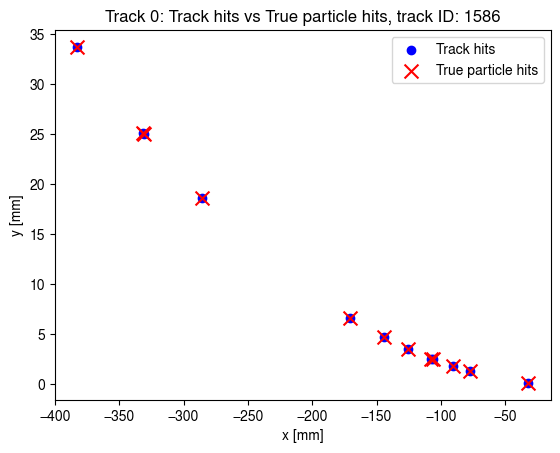

In [21]:
track_index = 0
track_hit_ids = parquet_track_hits_df.iloc[track_index].hit_ids

plt.scatter(parquet_trackerhits_df.x.iloc[track_hit_ids], parquet_trackerhits_df.y.iloc[track_hit_ids], marker='o', color="b", label="Track hits")

# Get the majority particle id for the track
track_majority_particle_id = parquet_tracks_df.iloc[track_index]['majority_particle_id']

# Get the hit ids for the majority particle id
majority_particle_hit_ids = parquet_trackerhits_df[parquet_trackerhits_df.particle_id == track_majority_particle_id].index.tolist()
plt.scatter(parquet_trackerhits_df.x.iloc[majority_particle_hit_ids], parquet_trackerhits_df.y.iloc[majority_particle_hit_ids], marker='x', color="red", s=100, label="True particle hits")

# Add legend
plt.legend()
plt.xlabel("x [mm]")
plt.ylabel("y [mm]")
plt.title(f"Track {track_index}: Track hits vs True particle hits, track ID: {parquet_tracks_df.track_id.iloc[track_index]}")

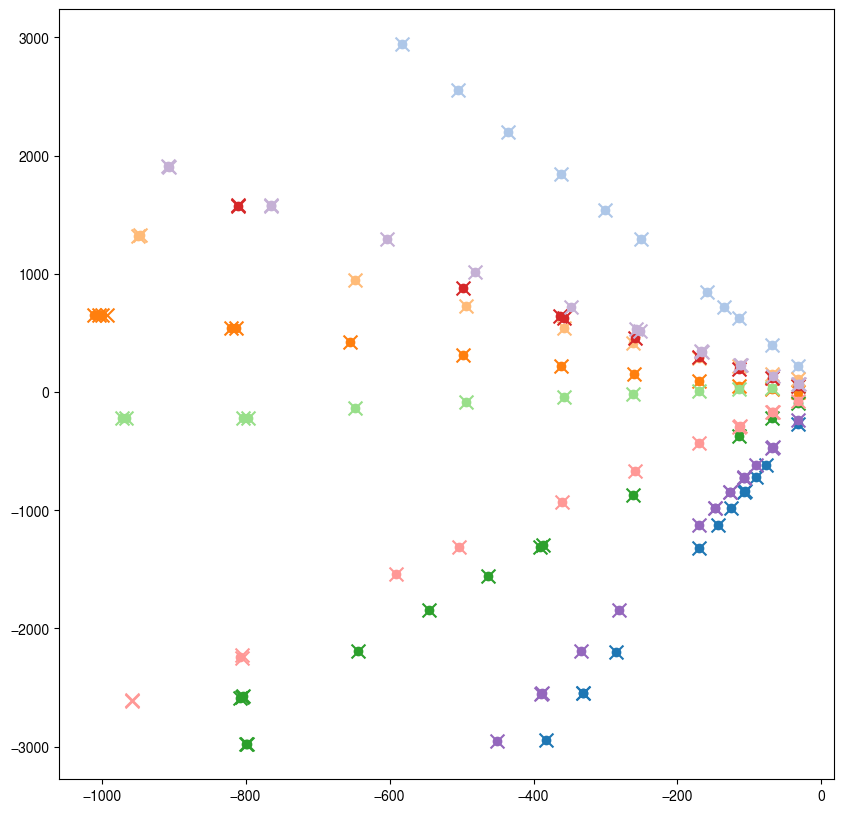

In [22]:
plt.figure(figsize=(10, 10))

num_tracks_to_sample = 10

# Define a list of colors to use for each track/particle pair
# Use tab20 colormap and cycle through it for more colors
cmap = plt.cm.tab20
colors = [cmap(i % 20) for i in range(num_tracks_to_sample)]

for i in range(num_tracks_to_sample):
    track_hit_ids = parquet_track_hits_df.iloc[i].hit_ids

    # Use the same color for both track hits and particle hits
    color = colors[i]
    
    plt.scatter(parquet_trackerhits_df.x.iloc[track_hit_ids], parquet_trackerhits_df.z.iloc[track_hit_ids], marker='o', color=color)

    # Get the majority particle id for the track
    track_majority_particle_id = parquet_tracks_df.iloc[i]['majority_particle_id']

    # Get the hit ids for the majority particle id
    majority_particle_hit_ids = parquet_trackerhits_df[parquet_trackerhits_df.particle_id == track_majority_particle_id].index.tolist()
    plt.scatter(parquet_trackerhits_df.x.iloc[majority_particle_hit_ids], parquet_trackerhits_df.z.iloc[majority_particle_hit_ids], marker='x', color=color, s=100)

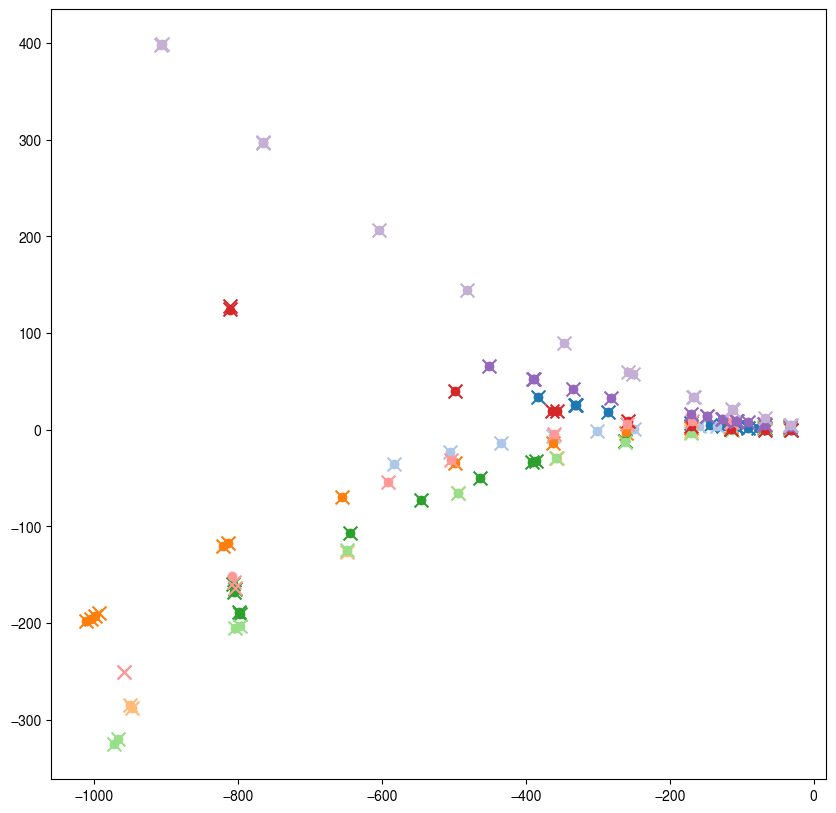

In [23]:
plt.figure(figsize=(10, 10))

num_tracks_to_sample = 10

# Define a list of colors to use for each track/particle pair
# Use tab20 colormap and cycle through it for more colors
cmap = plt.cm.tab20
colors = [cmap(i % 20) for i in range(num_tracks_to_sample)]

for i in range(num_tracks_to_sample):
    track_hit_ids = parquet_track_hits_df.iloc[i].hit_ids

    # Use the same color for both track hits and particle hits
    color = colors[i]
    
    plt.scatter(parquet_trackerhits_df.x.iloc[track_hit_ids], parquet_trackerhits_df.y.iloc[track_hit_ids], marker='o', color=color)

    # Get the majority particle id for the track
    track_majority_particle_id = parquet_tracks_df.iloc[i]['majority_particle_id']

    # Get the hit ids for the majority particle id
    majority_particle_hit_ids = parquet_trackerhits_df[parquet_trackerhits_df.particle_id == track_majority_particle_id].index.tolist()
    plt.scatter(parquet_trackerhits_df.x.iloc[majority_particle_hit_ids], parquet_trackerhits_df.y.iloc[majority_particle_hit_ids], marker='x', color=color, s=100)

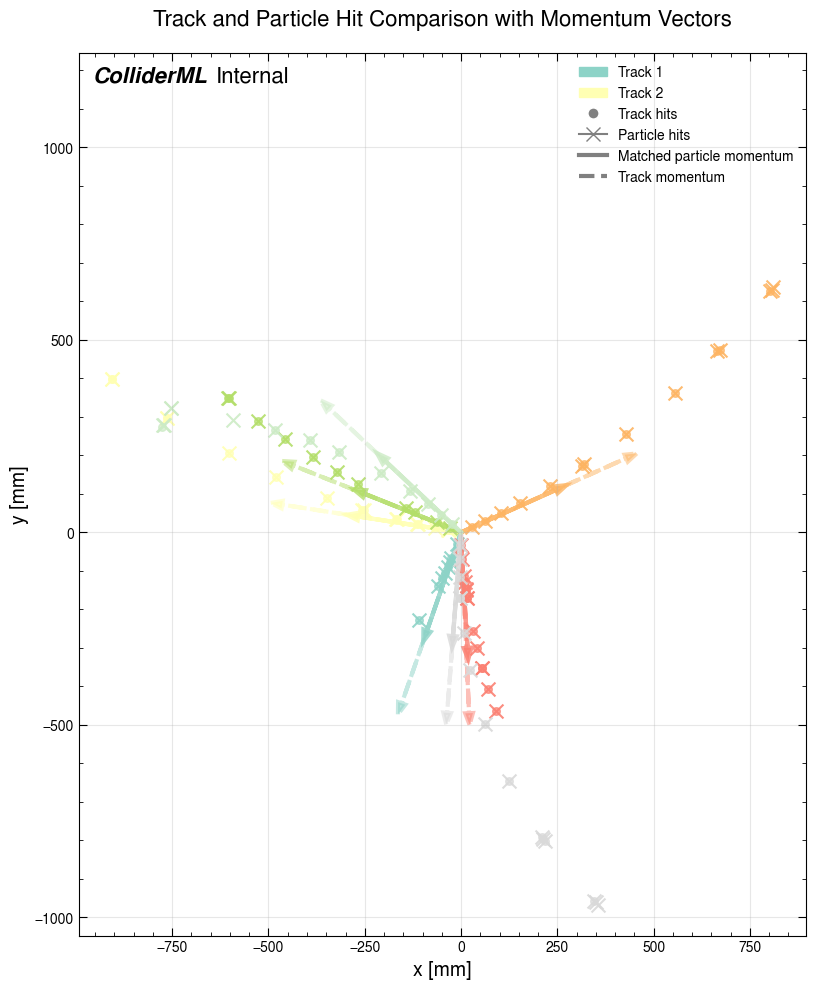

In [25]:
import matplotlib.patches as mpatches

plt.figure(figsize=(10, 10))
num_tracks_to_sample = 7

# Randomly sample track indices
track_indices = np.random.choice(len(parquet_tracks_df), size=min(num_tracks_to_sample, len(parquet_tracks_df)), replace=False)

# Use a pleasant colormap with more colors
cmap = plt.cm.Set3  # Set3 provides 12 distinct, pleasant colors
colors = [cmap(i / num_tracks_to_sample) for i in range(num_tracks_to_sample)]

legend_elements = []

for idx, track_idx in enumerate(track_indices):
    # Plot the track hits
    track_hit_ids = parquet_track_hits_df.iloc[track_idx].hit_ids
    track_scatter = plt.scatter(parquet_trackerhits_df.x.iloc[track_hit_ids], parquet_trackerhits_df.y.iloc[track_hit_ids], 
                               marker='o', color=colors[idx], s=30, alpha=0.7, 
                               label=f'Track {idx+1} hits')

    # Get the majority particle id for the track
    majority_particle_id = parquet_tracks_df.iloc[track_idx]['majority_particle_id']

    # Get the hit ids for the majority particle id
    majority_particle_hit_ids = parquet_trackerhits_df[parquet_trackerhits_df.particle_id == majority_particle_id].index.tolist()
    particle_scatter = plt.scatter(parquet_trackerhits_df.x.iloc[majority_particle_hit_ids], parquet_trackerhits_df.y.iloc[majority_particle_hit_ids], 
                                  marker='x', color=colors[idx], s=100, alpha=0.9,
                                  label=f'Particle {idx+1} hits')
    
    # Plot the phi vector of the particle as an arrow (solid arrow)
    particle_entry = parquet_particles_df[parquet_particles_df['particle_id'] == majority_particle_id].iloc[0]
    normalised_momentum_vector = particle_entry[['px', 'py']].values / np.linalg.norm(particle_entry[['px', 'py']].values)*300
    particle_arrow = plt.arrow(particle_entry['vx'], particle_entry['vy'], normalised_momentum_vector[0], normalised_momentum_vector[1], 
              color=colors[idx], head_width=20, head_length=30, length_includes_head=True, alpha=0.8, linewidth=3)
    phi = np.arctan2(particle_entry['py'], particle_entry['px'])

    # Plot the phi vector of the track (dashed arrow)
    track_entry = parquet_tracks_df.iloc[track_idx]
    phi = track_entry['phi']
    
    # Convert phi to px, py components (assuming unit momentum for visualization)
    track_px = np.cos(phi) * 500  # scale for visualization
    track_py = np.sin(phi) * 500
    
    # Plot from origin (assuming tracks start from origin for visualization)
    track_arrow = plt.arrow(0, 0, track_px, track_py, color=colors[idx], head_width=20, head_length=30, 
              length_includes_head=True, alpha=0.5, linewidth=3, linestyle='--')

# Create custom legend elements
legend_elements = [
    mpatches.Patch(color=colors[0], label='Track 1'),
    mpatches.Patch(color=colors[1], label='Track 2'),
    plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='gray', markersize=8, label='Track hits'),
    plt.Line2D([0], [0], marker='x', color='gray', markerfacecolor='gray', markersize=10, label='Particle hits'),
    plt.Line2D([0], [0], color='gray', linewidth=3, label='Matched particle momentum'),
    plt.Line2D([0], [0], color='gray', linewidth=3, linestyle='--', label='Track momentum')
]

plt.legend(handles=legend_elements, loc='upper right', frameon=True, fancybox=True, shadow=True)

plt.xlabel('x [mm]', fontsize=14)
plt.ylabel('y [mm]', fontsize=14)
plt.title('Track and Particle Hit Comparison with Momentum Vectors', fontsize=16, pad=20)

# Add ATLAS label
atl.atlasify("Internal")

plt.grid(True, alpha=0.3)
plt.gca().set_aspect('equal', 'box')
plt.tight_layout()
plt.show()


## EDM4HEP Version

In [26]:
run_size = 128
run_id = global_event_id // run_size
local_event = global_event_id % run_size

In [132]:
edm4hep_file = f"/global/cfs/cdirs/m4958/data/ColliderML/simulation/full_pileup/ttbar/v1/runs/{run_id}/edm4hep.root"
edm4hep_event = EDM4hepEventBatch(str(edm4hep_file), events=(local_event, local_event+2), condense_calo=False)

2025-10-29 04:26:29,536 - DEBUG - pyedm4hep.event_batch - EDM4hepEventBatch init: file=/global/cfs/cdirs/m4958/data/ColliderML/simulation/full_pileup/ttbar/v1/runs/0/edm4hep.root, events=(3, 5), full_load=False, condense_calo=False


In [140]:
# Compare edm4hep_contributions_df_original edm4hep_contributions_df_new
(edm4hep_contributions_df_original.cellID.values == edm4hep_contributions_df_new.cellID.values).all()

np.True_

,event_id,subentry,energy,time,particle_id,detector,hit_index,cellID,x,y,z
0,3,0,3.258480e-05,569.013733,79800,ECalBarrelCollection,0.0,26740084150239248,885.262329,-950.174744,479.399994
1,3,1,9.423339e-06,587.612671,79800,ECalBarrelCollection,1.0,23080900863066128,878.049866,-957.387207,413.100006
2,3,2,3.327382e-06,597.462158,79800,ECalBarrelCollection,2.0,21673530274480144,881.656067,-953.781006,387.600006
3,3,3,5.303359e-06,612.921509,79800,ECalBarrelCollection,3.0,19984697593823248,881.797485,-925.072449,357.000000
4,3,4,1.747833e-05,4.585382,79846,ECalBarrelCollection,4.0,18420285284182736912,-823.708679,1061.720825,-484.500000
...,...,...,...,...,...,...,...,...,...,...,...
12328436,4,1425317,1.509956e-04,46.963360,244663,HCalEndcapCollection,2538435.0,3940636801714452,-778.841125,2115.470215,3647.500000
12328437,4,1425318,8.330935e-10,1947.285889,262,HCalEndcapCollection,2538436.0,18441677541321277716,1019.993835,-850.288208,3647.500000
12328438,4,1425319,2.138461e-09,1978.072021,262,HCalEndcapCollection,2538436.0,18441677541321277716,1019.993835,-850.288208,3647.500000
12328439,4,1425320,1.997375e-07,487.965118,262,HCalEndcapCollection,2538437.0,18435485083244101908,510.876953,-426.024139,3953.500000


In [127]:
edm4hep_trackerhits_df = edm4hep_event.get_tracker_hits_df()
edm4hep_calohits_df = edm4hep_event.get_calo_hits_df()
edm4hep_contributions_df = edm4hep_event.get_calo_contributions_df()
edm4hep_particles_df = edm4hep_event.get_particles_df()

2025-10-29 04:16:30,325 - DEBUG - pyedm4hep.event_batch - _load_tracker_hits: start=3, stop=5
2025-10-29 04:16:30,653 - DEBUG - pyedm4hep.event_batch - tracker PixelBarrelReadout: rows=100315 cols=['event_id', 'subentry', 'cellID', 'time', 'x', 'y', 'z', 'detector']
2025-10-29 04:16:30,822 - DEBUG - pyedm4hep.event_batch - tracker PixelEndcapReadout: rows=96608 cols=['event_id', 'subentry', 'cellID', 'time', 'x', 'y', 'z', 'detector']
2025-10-29 04:16:30,986 - DEBUG - pyedm4hep.event_batch - tracker ShortStripBarrelReadout: rows=103063 cols=['event_id', 'subentry', 'cellID', 'time', 'x', 'y', 'z', 'detector']
2025-10-29 04:16:31,213 - DEBUG - pyedm4hep.event_batch - tracker ShortStripEndcapReadout: rows=93741 cols=['event_id', 'subentry', 'cellID', 'time', 'x', 'y', 'z', 'detector']
2025-10-29 04:16:31,552 - DEBUG - pyedm4hep.event_batch - tracker LongStripBarrelReadout: rows=47002 cols=['event_id', 'subentry', 'cellID', 'time', 'x', 'y', 'z', 'detector']
2025-10-29 04:16:31,669 - DEBU

Any NAN values:  event_id       False
subentry       False
energy         False
time           False
particle_id    False
detector       False
hit_index      False
cellID         False
x              False
y              False
z              False
dtype: bool


2025-10-29 04:16:45,937 - DEBUG - pyedm4hep.event_batch - _load_particles_and_links: start=3, stop=5
2025-10-29 04:16:46,313 - DEBUG - pyedm4hep.event_batch - particles columns after rename: ['event_id', 'subentry', 'PDG', 'simulatorStatus', 'charge', 'time', 'mass', 'vx', 'vy', 'vz', 'px', 'py', 'pz', 'parents_begin', 'parents_end'] rows=443906
2025-10-29 04:16:46,314 - INFO - pyedm4hep.event_batch -   ↳ particles loaded: 0.3761s (443906 rows)
2025-10-29 04:16:46,389 - INFO - pyedm4hep.event_batch -   ↳ links loaded: 0.0690s (parents=771674, daughters=0)
2025-10-29 04:16:46,390 - INFO - pyedm4hep.event_batch - ⏱️  _load_particles_and_links: 0.5516s total
2025-10-29 04:16:46,390 - DEBUG - pyedm4hep.event_batch - augment_particles: input particles rows=443906, cols=['event_id', 'subentry', 'PDG', 'simulatorStatus', 'charge', 'time', 'mass', 'vx', 'vy', 'vz', 'px', 'py', 'pz', 'parents_begin', 'parents_end', 'vr', 'energy', 'kinetic_energy']
2025-10-29 04:16:46,391 - DEBUG - pyedm4hep.ev

In [38]:
edm4hep_trackerhits_df

,event_id,subentry,cellID,time,x,y,z,detector,particle_id,r,R,phi,theta,eta
0,3,0,71916830779769350,-1.152176,23.156928,22.447815,-471.701793,PixelBarrelReadout,79703,32.251321,472.803056,0.769850,3.073327,-3.377102
1,3,1,65197199826684678,-2.303055,-6.266931,-31.428991,-128.228912,PixelBarrelReadout,79750,32.047713,132.173030,-1.767615,2.896684,-2.095001
2,3,2,62926691135458310,-2.280472,-6.650207,-32.988839,-134.764750,PixelBarrelReadout,79750,33.652471,138.902939,-1.769720,2.896884,-2.095828
3,3,3,63753833117062934,-1.789064,-16.412054,-66.638902,-277.382531,PixelBarrelReadout,79750,68.630159,285.746683,-1.812274,2.899043,-2.104777
4,3,4,3783037259097126,-1.158029,-32.582734,-108.722908,-460.488911,PixelBarrelReadout,79750,113.500243,474.270326,-1.861965,2.899932,-2.108484
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
226918,3,23805,283468960078,8.795395,-617.613371,819.906135,2609.500000,LongStripEndcapReadout,199193,1026.495176,2804.136693,2.216389,0.374777,1.662771
226919,3,23806,257698107726,8.813107,-617.577765,820.946672,2604.500000,LongStripEndcapReadout,199193,1027.305083,2799.781417,2.215752,0.375699,1.660253
226920,3,23807,206159548734,10.117831,-620.317832,819.051037,2259.500000,LongStripEndcapReadout,199193,1027.442852,2482.131960,2.218992,0.426773,1.529308
226921,3,23808,386548175198,7.178246,-598.834171,802.118511,3009.441433,LongStripEndcapReadout,199195,1000.997738,3171.550758,2.212096,0.321108,1.820482


In [39]:
parquet_trackerhits_df

,event_id,x,y,z,time,particle_id,true_x,true_y,true_z,volume_id,layer_id,surface_id,cell_id,detector
0,3,68.875000,4.275000,-1515.599976,-6.426563,4818,68.892258,4.279866,-1515.599976,16,4,1,17222818857063,1
1,3,84.074997,10.075000,-1515.599976,-3.775208,126355,84.093315,10.075608,-1515.599976,16,4,1,16724602650727,1
2,3,49.674999,-2.475000,-1515.599976,-3.700859,42228,49.696224,-2.497706,-1515.599976,16,4,1,214748364903,1
3,3,59.988514,1.575000,-1515.599976,-3.697997,41588,59.998993,1.598492,-1515.599976,16,4,1,17454747091047,1
4,3,80.724998,2.225000,-1515.599976,-3.673765,125981,80.718239,2.211451,-1515.599976,16,4,1,17403207483495,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
226915,3,426.064301,896.183899,3009.500000,25.932676,99536,412.230408,860.813538,3009.500000,30,12,192,1451700031838,5
226916,3,388.577545,910.840149,3009.500000,33.034550,97463,378.397644,884.828186,3009.500000,30,12,192,300648796510,5
226917,3,425.482208,896.411438,3009.500000,40.365749,97462,434.520691,919.563965,3009.500000,30,12,192,1434520162654,5
226918,3,373.384918,916.780029,3009.500000,62.342796,116732,369.244568,906.176147,3009.483398,30,12,192,17424683405662,5


In [44]:
df1 = edm4hep_trackerhits_df[["x", "y", "z"]].astype(np.float32)
df2 = parquet_trackerhits_df[["true_x", "true_y", "true_z"]].astype(np.float32)
df1.columns = ["x", "y", "z"]
df2.columns = ["x", "y", "z"]
merged_hits = df1.merge(df2, on=["x", "y", "z"], how="inner")
print(f"{len(merged_hits)} out of {len(edm4hep_trackerhits_df)} hits match within tolerance.")

226922 out of 226923 hits match within tolerance.


In [45]:
# Test vx, vy, vz (_x and _y are the same)
merged_particles = parquet_particles_df.merge(edm4hep_particles_df, on="particle_id", how="inner", suffixes=("_parquet", "_edm4hep"))
df1 = merged_particles[["vx_parquet", "vy_parquet", "vz_parquet", "px_parquet", "py_parquet", "pz_parquet"]].astype(np.float32)
df2 = merged_particles[["vx_edm4hep", "vy_edm4hep", "vz_edm4hep", "px_edm4hep", "py_edm4hep", "pz_edm4hep"]].astype(np.float32)
df1.columns = ["vx", "vy", "vz", "px", "py", "pz"]
df2.columns = ["vx", "vy", "vz", "px", "py", "pz"]
comparison = (df1 - df2).abs() < 1e-4  # adjust tolerance if needed
comparison_all = comparison.all(axis=1)
print(f"{comparison_all.sum()} out of {len(comparison_all)} particles match within tolerance.")

# Optionally, show where mismatches occur
if not comparison_all.all():
    mismatches = pd.concat([df1[~comparison_all], df2[~comparison_all]], axis=1, keys=["edm4hep", "parquet"])
    print("Mismatching particles:")
    delta = merged_particles[f"{col}_parquet"] - merged_particles[f"{col}_edm4hep"]
    print(f"Max delta: {delta.abs().max()}")
    print("\n")

161924 out of 161924 particles match within tolerance.


In [52]:
merged_particles

,event_id_parquet,particle_id,pdg_id,mass_parquet,energy_parquet,charge_parquet,vx_parquet,vy_parquet,vz_parquet,time_parquet,...,py_edm4hep,pz_edm4hep,parents_begin,parents_end,vr,energy_edm4hep,kinetic_energy,created_in_simulation,num_tracker_hits_edm4hep,num_calo_hits_edm4hep
0,3,108,-521,5.279250,65.589457,-1.0,-0.014461,0.002710,65.368271,-8.741320,...,30.374715,8.255796e+00,107,121,0.014713,65.589457,60.310207,False,0,0
1,3,109,211,0.139570,2.217242,1.0,-0.014461,0.002710,65.368271,-8.741320,...,0.698589,4.475743e-01,121,135,0.014713,2.217242,2.077672,False,16,282
2,3,110,-211,0.139570,3.711000,-1.0,-0.014461,0.002710,65.368271,-8.741320,...,2.360660,7.894119e-01,135,149,0.014713,3.711000,3.571430,False,14,43
3,3,111,223,0.770946,2.193753,0.0,-0.014461,0.002710,65.368271,-8.741320,...,0.426775,3.376200e-01,149,163,0.014713,2.193753,1.422807,False,0,0
4,3,112,211,0.139570,1.583310,1.0,-0.014461,0.002710,65.368271,-8.741320,...,0.754529,-6.042511e-01,163,177,0.014713,1.583310,1.443740,False,14,186
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
161919,3,199202,22,0.000000,0.000006,0.0,-52.454369,-108.849030,391.933868,-7.186817,...,-0.000005,-6.540071e-07,343722,343723,120.828691,0.000006,0.000006,True,1,0
161920,3,199203,11,0.000511,0.000515,-1.0,-68.117104,-155.346069,386.271667,-7.022070,...,-0.000047,-1.001093e-05,343723,343724,169.624121,0.000515,0.000004,True,1,0
161921,3,199204,11,0.000511,0.000516,-1.0,-46.777748,-103.543541,352.654114,-7.476046,...,0.000066,3.009286e-05,343724,343725,113.619637,0.000516,0.000005,True,1,0
161922,3,199205,11,0.000511,0.000517,-1.0,-46.745773,-105.281052,313.242188,-7.659314,...,0.000078,-1.249977e-05,343725,343726,115.192302,0.000517,0.000006,True,1,0


In [51]:
edm4hep_particles_df

,event_id,subentry,PDG,simulatorStatus,charge,time,mass,vx,vy,vz,...,pz,parents_begin,parents_end,vr,energy,kinetic_energy,particle_id,created_in_simulation,num_tracker_hits,num_calo_hits
0,3,0,2212,0,1.000000,0.000000,0.938270,0.000000,0.000000,0.000000,...,7.000000e+03,0,0,0.000000,7000.000000,6999.061730,0,False,0,0
1,3,1,21,0,0.000000,-8.741320,0.000000,-0.014461,0.002710,65.368268,...,1.332510e+02,0,1,0.014713,133.251010,133.251010,1,False,0,0
2,3,2,2101,0,0.333333,-8.741320,0.579330,-0.014461,0.002710,65.368268,...,1.491667e+03,1,2,0.014713,1491.666755,1491.087425,2,False,0,0
3,3,3,2,0,0.666667,-8.741320,0.330000,-0.014461,0.002710,65.368268,...,5.375082e+03,2,3,0.014713,5375.082213,5374.752213,3,False,0,0
4,3,4,2212,0,1.000000,0.000000,0.938270,0.000000,0.000000,0.000000,...,-7.000000e+03,3,3,0.000000,7000.000000,6999.061730,4,False,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
199202,3,199202,22,1493172224,0.000000,-7.186817,0.000000,-52.454370,-108.849031,391.933874,...,-6.540071e-07,343722,343723,120.828691,0.000006,0.000006,199202,True,1,0
199203,3,199203,11,1224736768,-1.000000,-7.022070,0.000511,-68.117101,-155.346075,386.271672,...,-1.001093e-05,343723,343724,169.624121,0.000515,0.000004,199203,True,1,0
199204,3,199204,11,1224736768,-1.000000,-7.476046,0.000511,-46.777749,-103.543538,352.654112,...,3.009286e-05,343724,343725,113.619637,0.000516,0.000005,199204,True,1,0
199205,3,199205,11,1493172224,-1.000000,-7.659314,0.000511,-46.745773,-105.281048,313.242173,...,-1.249977e-05,343725,343726,115.192302,0.000517,0.000006,199205,True,1,0


In [53]:
# Check that all generator particles are present from the edm4hep collection
edm4hep_generator_particles = edm4hep_particles_df[edm4hep_particles_df.created_in_simulation == False]
parquet_generator_particles = merged_particles[merged_particles.created_in_simulation == False]
print(f"Number of generator particles in edm4hep: {len(edm4hep_generator_particles)}")
print(f"Number of generator particles in parquet: {len(parquet_generator_particles)}")

edm4hep_particles_with_hits = edm4hep_particles_df[(edm4hep_particles_df.num_tracker_hits > 0) | (edm4hep_particles_df.num_calo_hits > 0)]
parquet_particles_with_hits = merged_particles[(merged_particles.num_tracker_hits_edm4hep > 0) | (merged_particles.num_calo_hits_edm4hep > 0)]
print(f"Number of particles with hits in edm4hep: {len(edm4hep_particles_with_hits)}")
print(f"Number of particles with hits in parquet: {len(parquet_particles_with_hits)}")


Number of generator particles in edm4hep: 79824
Number of generator particles in parquet: 42541
Number of particles with hits in edm4hep: 124177
Number of particles with hits in parquet: 124177


In [54]:
# Cast all x,y,z to float32
parquet_calohits_df = parquet_calohits_df.astype({"x": np.float32, "y": np.float32, "z": np.float32})
edm4hep_calohits_df = edm4hep_calohits_df.astype({"x": np.float32, "y": np.float32, "z": np.float32})
merged_calo = parquet_calohits_df.merge(edm4hep_calohits_df, on=["x", "y", "z"], how="inner")
print(f"{len(merged_calo)} out of {len(edm4hep_calohits_df)} calo hits match within tolerance.")

456825 out of 1154889 calo hits match within tolerance.


## HepMC Version

#### Hard Scatter

In [55]:
hepmc_hs_file = f"/global/cfs/cdirs/m4958/data/ColliderML/simulation/full_pileup/ttbar/v1/runs/{run_id}/events.hepmc"

In [56]:
root_file = uproot.open(edm4hep_file)["events"]

In [57]:
hepmc_event_number = root_file["EventHeader/EventHeader.eventNumber"].arrays()[local_event]["EventHeader.eventNumber"].tolist()[0]
print(f"HepMC event number: {hepmc_event_number}")

In [58]:
hepmc_event_number

6

In [79]:
with hep.open(str(hepmc_hs_file)) as f:
    for i, evt in enumerate(f):
        if evt.event_number == hepmc_event_number:
            hepmc_hs_event = evt
            break
hepmc_hs_event

<GenEvent momentum_unit=1, length_unit=0, event_number=6, particles=431, vertices=226, run_info=GenRunInfo(tools=[], weight_names=['0', 'AUX_1010', 'AUX_1011', 'AUX_1012', 'AUX_1013', 'AUX_1014', 'AUX_1015', 'AUX_1016', 'AUX_1017', 'AUX_1018', 'AUX_1019', 'AUX_1020', 'AUX_1021', 'AUX_1022', 'AUX_1023', 'AUX_1024', 'AUX_1025', 'AUX_1026', 'AUX_1027', 'AUX_1028', 'AUX_1029', 'AUX_1030', 'AUX_1031', 'AUX_1032', 'AUX_1033', 'AUX_1034', 'AUX_1035', 'AUX_1036', 'AUX_1037', 'AUX_1038', 'AUX_1039', 'AUX_1040', 'AUX_1041', 'AUX_1042', 'AUX_1043', 'AUX_1044', 'AUX_1045', 'AUX_MUR0.5_MUF0.5', 'AUX_MUR0.5_MUF1.0', 'AUX_MUR0.5_MUF2.0', 'AUX_MUR1.0_MUF0.5', 'AUX_MUR1.0_MUF1.0', 'AUX_MUR1.0_MUF2.0', 'AUX_MUR2.0_MUF0.5', 'AUX_MUR2.0_MUF1.0', 'AUX_MUR2.0_MUF2.0', 'Weight'], attributes={})>

In [80]:
hepmc_hs_momentum_df = pd.DataFrame(
    {
        "px": hepmc_hs_event.numpy.particles.px,
        "py": hepmc_hs_event.numpy.particles.py,
        "pz": hepmc_hs_event.numpy.particles.pz
    }
).astype(np.float32)
hepmc_hs_momentum_df

,px,py,pz
0,0.000000e+00,0.000000,7000.000000
1,2.524355e-29,0.000000,133.251007
2,0.000000e+00,0.000000,1491.666626
3,0.000000e+00,0.000000,5375.082031
4,0.000000e+00,0.000000,-7000.000000
...,...,...,...
426,-6.647501e-01,-1.316397,-2.987322
427,3.836993e-01,1.939023,-31.733995
428,4.324381e-01,0.426847,-19.735107
429,-2.141925e-01,0.909790,-20.239527


In [114]:
hepmc_hs_momentum_df.drop_duplicates(subset=["px", "py", "pz"])

,px,py,pz
0,0.000000e+00,0.000000,7000.000000
1,2.524355e-29,0.000000,133.251007
2,0.000000e+00,0.000000,1491.666626
3,0.000000e+00,0.000000,5375.082031
4,0.000000e+00,0.000000,-7000.000000
...,...,...,...
426,-6.647501e-01,-1.316397,-2.987322
427,3.836993e-01,1.939023,-31.733995
428,4.324381e-01,0.426847,-19.735107
429,-2.141925e-01,0.909790,-20.239527


In [84]:
merged_particles.vertex_primary.unique()

array([  1,   2,   3,   4,   5,   6,   7,   8,   9,  10,  11,  12,  13,
        14,  15,  16,  17,  18,  19,  20,  21,  22,  23,  24,  25,  26,
        27,  28,  29,  30,  31,  32,  33,  34,  35,  36,  37,  38,  39,
        40,  41,  42,  43,  44,  45,  46,  47,  48,  49,  50,  51,  52,
        53,  54,  55,  56,  57,  58,  59,  60,  61,  62,  63,  64,  65,
        66,  67,  68,  69,  70,  71,  72,  73,  74,  75,  76,  77,  78,
        79,  80,  81,  82,  83,  84,  85,  86,  87,  88,  89,  90,  91,
        92,  93,  94,  95,  96,  97,  98,  99, 100, 101, 102, 103, 104,
       105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117,
       118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129, 130,
       131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142, 143,
       144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155, 156,
       157, 158, 159, 160, 161, 162, 163, 164, 165, 166, 167, 168, 169,
       170, 171, 172, 173, 174, 175])

In [88]:
merged_particles.columns

Index(['event_id_parquet', 'particle_id', 'pdg_id', 'mass_parquet',
       'energy_parquet', 'charge_parquet', 'vx_parquet', 'vy_parquet',
       'vz_parquet', 'time_parquet', 'px_parquet', 'py_parquet', 'pz_parquet',
       'num_tracker_hits_parquet', 'num_calo_hits_parquet', 'vertex_primary',
       'parent_id', 'event_id_edm4hep', 'subentry', 'PDG', 'simulatorStatus',
       'charge_edm4hep', 'time_edm4hep', 'mass_edm4hep', 'vx_edm4hep',
       'vy_edm4hep', 'vz_edm4hep', 'px_edm4hep', 'py_edm4hep', 'pz_edm4hep',
       'parents_begin', 'parents_end', 'vr', 'energy_edm4hep',
       'kinetic_energy', 'created_in_simulation', 'num_tracker_hits_edm4hep',
       'num_calo_hits_edm4hep'],
      dtype='object')

In [90]:
merged_particles.groupby("vertex_primary")["num_tracker_hits_edm4hep"].sum()

vertex_primary
1      2932
2         0
3       958
4      4528
5      4415
       ... 
171       0
172       0
173       0
174    4796
175     660
Name: num_tracker_hits_edm4hep, Length: 175, dtype: int64

In [125]:
merged_particles[merged_particles.created_in_simulation == False].groupby("vertex_primary")["energy_parquet"].sum()

vertex_primary
1      24146.088308
2      14000.000000
3      24474.211790
4      24718.310184
5      25107.442118
           ...     
171    14000.000000
172    14000.000000
173    14000.000000
174    31281.787686
175    30139.049620
Name: energy_parquet, Length: 175, dtype: float64

In [106]:
hs_merged_particles = merged_particles[merged_particles.vertex_primary == 1]
hs_generator_particles = hs_merged_particles[hs_merged_particles.created_in_simulation == False].astype({"px_parquet": np.float32, "py_parquet": np.float32, "pz_parquet": np.float32})

In [107]:
hs_generator_particles

,event_id_parquet,particle_id,pdg_id,mass_parquet,energy_parquet,charge_parquet,vx_parquet,vy_parquet,vz_parquet,time_parquet,...,py_edm4hep,pz_edm4hep,parents_begin,parents_end,vr,energy_edm4hep,kinetic_energy,created_in_simulation,num_tracker_hits_edm4hep,num_calo_hits_edm4hep
0,3,108,-521,5.279250,65.589457,-1.0,-0.014461,0.00271,65.368271,-8.74132,...,30.374715,8.255796,107,121,0.014713,65.589457,60.310207,False,0,0
1,3,109,211,0.139570,2.217242,1.0,-0.014461,0.00271,65.368271,-8.74132,...,0.698589,0.447574,121,135,0.014713,2.217242,2.077672,False,16,282
2,3,110,-211,0.139570,3.711000,-1.0,-0.014461,0.00271,65.368271,-8.74132,...,2.360660,0.789412,135,149,0.014713,3.711000,3.571430,False,14,43
3,3,111,223,0.770946,2.193753,0.0,-0.014461,0.00271,65.368271,-8.74132,...,0.426775,0.337620,149,163,0.014713,2.193753,1.422807,False,0,0
4,3,112,211,0.139570,1.583310,1.0,-0.014461,0.00271,65.368271,-8.74132,...,0.754529,-0.604251,163,177,0.014713,1.583310,1.443740,False,14,186
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
233,3,426,111,0.134980,3.334236,0.0,-0.014461,0.00271,65.368271,-8.74132,...,-1.316398,-2.987325,1231,1232,0.014713,3.334236,3.199256,False,0,0
234,3,427,211,0.139570,31.795802,1.0,-0.014461,0.00271,65.368271,-8.74132,...,1.939023,-31.733996,1232,1233,0.014713,31.795802,31.656232,False,7,33
235,3,428,-211,0.139570,19.744953,-1.0,-0.014461,0.00271,65.368271,-8.74132,...,0.426847,-19.735108,1233,1234,0.014713,19.744953,19.605383,False,2,0
236,3,429,-211,0.139570,20.261577,-1.0,-0.014461,0.00271,65.368271,-8.74132,...,0.909790,-20.239526,1234,1235,0.014713,20.261577,20.122007,False,4,0


In [124]:
print(f"There are {len(hepmc_hs_momentum_df)} particles in the HEPMC hard scatter event")
print(f"There are {len(hs_generator_particles)} generator particles in the HEPMC hard scatter event")

# Exact float32 precision overlap
merged_hepmc_parquet_hs = hepmc_hs_momentum_df.merge(
    hs_generator_particles, 
    left_on=["px", "py", "pz"], 
    right_on=["px_parquet", "py_parquet", "pz_parquet"], 
    how="inner"
)
print(f"There are {len(merged_hepmc_parquet_hs)} particles in the HEPMC hard scatter event that are PERFECTLY (float32 precision) in the parquet hard scatter event")

# Now overlap within 0.1% and 1% relative difference
def get_presence_count(hs_gen_df, hepmc_df, threshold):
    hs_px = hs_gen_df["px_parquet"].values
    hs_py = hs_gen_df["py_parquet"].values
    hs_pz = hs_gen_df["pz_parquet"].values
    hepmc_px = hepmc_df["px"].values
    hepmc_py = hepmc_df["py"].values
    hepmc_pz = hepmc_df["pz"].values

    count = 0
    for i in range(len(hs_gen_df)):
        # Compute relative differences
        px_diff = np.abs(hs_px[i] - hepmc_px) / np.clip(np.abs(hs_px[i]), 1e-10, None)
        py_diff = np.abs(hs_py[i] - hepmc_py) / np.clip(np.abs(hs_py[i]), 1e-10, None)
        pz_diff = np.abs(hs_pz[i] - hepmc_pz) / np.clip(np.abs(hs_pz[i]), 1e-10, None)
        mean_diff = (px_diff + py_diff + pz_diff) / 3.0
        # If *any* of the differences for this particle is below threshold, count as present
        if np.any(mean_diff < threshold):
            count += 1
    return count

count_0p1 = get_presence_count(hs_generator_particles, hepmc_hs_momentum_df, 0.001)
count_1 = get_presence_count(hs_generator_particles, hepmc_hs_momentum_df, 0.01)

print(f"There are {count_0p1} generator particles in the HEPMC hard scatter event that match to a HEPMC particle within 0.1% relative mean (px/py/pz) difference")
print(f"There are {count_1} generator particles in the HEPMC hard scatter event that match to a HEPMC particle within 1% relative mean (px/py/pz) difference")



There are 431 particles in the HEPMC hard scatter event
There are 238 generator particles in the HEPMC hard scatter event
There are 140 particles in the HEPMC hard scatter event that are PERFECTLY (float32 precision) in the parquet hard scatter event
There are 233 generator particles in the HEPMC hard scatter event that match to a HEPMC particle within 0.1% relative mean (px/py/pz) difference
There are 236 generator particles in the HEPMC hard scatter event that match to a HEPMC particle within 1% relative mean (px/py/pz) difference


In [116]:
hepmc_hs_momentum_df.sort_values(by=["px", "py", "pz"], ascending=False).drop_duplicates(subset=["px", "py", "pz"])

,px,py,pz
263,68.198769,19.614685,-30.775137
105,59.953262,6.350095,-10.943170
207,45.309929,32.376404,-87.528503
208,42.886589,32.661842,-83.545898
210,37.335453,28.329103,-72.820251
...,...,...,...
206,-46.047928,-64.298164,-345.965179
382,-46.082752,-69.955368,-191.283234
370,-46.278019,-69.879105,-187.995895
108,-57.300304,30.374716,8.255796


In [121]:
hepmc_hs_momentum_df.sort_values(by=["px", "py", "pz"], ascending=False).drop_duplicates(subset=["px", "py", "pz"]).iloc[0:10]

,px,py,pz
263,68.198769,19.614685,-30.775137
105,59.953262,6.350095,-10.943170
207,45.309929,32.376404,-87.528503
208,42.886589,32.661842,-83.545898
210,37.335453,28.329103,-72.820251
250,36.988705,28.152205,-73.006973
351,36.505341,27.757849,-71.975166
373,20.137781,12.648202,-36.774624
388,18.095814,11.217611,-32.574028
372,16.367559,15.109648,-35.200542


In [120]:
hs_generator_particles.sort_values(by=["px_parquet", "py_parquet", "pz_parquet"], ascending=False)[["px_parquet", "py_parquet", "pz_parquet"]].drop_duplicates(subset=["px_parquet", "py_parquet", "pz_parquet"]).iloc[0:10]

,px_parquet,py_parquet,pz_parquet
87,68.198769,19.614685,-30.775137
78,36.988705,28.152205,-73.006973
174,36.505341,27.757849,-71.975166
194,20.170153,12.668534,-36.833740
206,18.095816,11.217612,-32.574032
193,16.367559,15.109648,-35.200542
203,15.216469,14.038689,-32.643391
209,6.284658,5.956151,-13.509079
212,5.619682,4.506317,-10.998408
73,2.653015,1.753748,-7.792339


In [122]:
hs_generator_particles.sort_values(by=["px_edm4hep", "py_edm4hep", "pz_edm4hep"], ascending=False)[["px_edm4hep", "py_edm4hep", "pz_edm4hep"]].drop_duplicates(subset=["px_edm4hep", "py_edm4hep", "pz_edm4hep"]).iloc[0:10]

,px_edm4hep,py_edm4hep,pz_edm4hep
87,68.198765,19.614685,-30.775137
184,68.198765,19.614685,-30.775137
78,36.988706,28.152204,-73.006972
174,36.505342,27.757850,-71.975167
194,20.170154,12.668534,-36.833741
206,18.095816,11.217612,-32.574032
193,16.367560,15.109647,-35.200541
203,15.216469,14.038689,-32.643389
209,6.284659,5.956151,-13.509079
212,5.619682,4.506317,-10.998408


In [109]:
merged_hepmc_parquet_hs

,px,py,pz,event_id_parquet,particle_id,pdg_id,mass_parquet,energy_parquet,charge_parquet,vx_parquet,...,py_edm4hep,pz_edm4hep,parents_begin,parents_end,vr,energy_edm4hep,kinetic_energy,created_in_simulation,num_tracker_hits_edm4hep,num_calo_hits_edm4hep
0,-57.300304,30.374716,8.255796,3,108,-521,5.279250,65.589457,-1.0,-0.014461,...,30.374715,8.255796,107,121,0.014713,65.589457,60.310207,False,0,0
1,-2.051422,0.698589,0.447574,3,109,211,0.139570,2.217242,1.0,-0.014461,...,0.698589,0.447574,121,135,0.014713,2.217242,2.077672,False,16,282
2,-2.748846,2.360660,0.789412,3,110,-211,0.139570,3.711000,-1.0,-0.014461,...,2.360660,0.789412,135,149,0.014713,3.711000,3.571430,False,14,43
3,-1.980422,0.426775,0.337620,3,111,223,0.770946,2.193753,0.0,-0.014461,...,0.426775,0.337620,149,163,0.014713,2.193753,1.422807,False,0,0
4,-1.246177,0.754529,-0.604251,3,112,211,0.139570,1.583310,1.0,-0.014461,...,0.754529,-0.604251,163,177,0.014713,1.583310,1.443740,False,14,186
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
135,-0.319166,2.455553,-78.592262,3,418,-213,0.770184,78.635036,-1.0,-0.014461,...,2.455553,-78.592265,1219,1224,0.014713,78.635036,77.864852,False,0,0
136,-16.232010,-24.667612,-66.521919,3,419,-211,0.139570,72.781555,-1.0,-0.014461,...,-24.667612,-66.521921,1224,1225,0.014713,72.781555,72.641985,False,13,1008
137,0.383699,1.939023,-31.733995,3,427,211,0.139570,31.795802,1.0,-0.014461,...,1.939023,-31.733996,1232,1233,0.014713,31.795802,31.656232,False,7,33
138,0.432438,0.426847,-19.735107,3,428,-211,0.139570,19.744953,-1.0,-0.014461,...,0.426847,-19.735108,1233,1234,0.014713,19.744953,19.605383,False,2,0


In [110]:
# Get those hs_generator_particles that are not in the merged_hepmc_parquet_hs
missing_particles = hs_generator_particles[~hs_generator_particles.particle_id.isin(merged_hepmc_parquet_hs.particle_id)]
missing_particles


,event_id_parquet,particle_id,pdg_id,mass_parquet,energy_parquet,charge_parquet,vx_parquet,vy_parquet,vz_parquet,time_parquet,...,py_edm4hep,pz_edm4hep,parents_begin,parents_end,vr,energy_edm4hep,kinetic_energy,created_in_simulation,num_tracker_hits_edm4hep,num_calo_hits_edm4hep
88,3,264,-20213,1.25228,26.531042,-1.0,-2.832186,1.496297,65.774239,-8.730561,...,10.425018,3.330504,1017,1018,3.203152,26.531042,25.278762,False,0,0
89,3,265,421,1.86486,39.079671,0.0,-2.832186,1.496297,65.774239,-8.730561,...,19.955536,4.927957,1018,1019,3.203152,39.079671,37.214811,False,0,0
90,3,266,211,0.13957,0.720156,1.0,-0.014461,0.002710,65.368271,-8.741320,...,0.007517,0.094854,1019,1020,0.014713,0.720156,0.580586,False,15,74
91,3,267,-211,0.13957,1.165974,-1.0,-0.014461,0.002710,65.368271,-8.741320,...,0.490930,0.264934,1020,1021,0.014713,1.165974,1.026404,False,12,0
92,3,268,111,0.13498,0.307625,0.0,-0.014461,0.002710,65.368271,-8.741320,...,-0.071673,-0.022168,1021,1022,0.014713,0.307625,0.172645,False,0,52
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
230,3,423,-321,0.49368,21.511911,-1.0,-0.014461,0.002710,65.368271,-8.741320,...,-7.288554,-19.683072,1228,1229,0.014713,21.511911,21.018231,False,15,1687
231,3,424,111,0.13498,1.573532,0.0,-0.014461,0.002710,65.368271,-8.741320,...,-0.603373,-1.429559,1229,1230,0.014713,1.573532,1.438552,False,0,0
232,3,425,211,0.13957,0.913562,1.0,-0.014461,0.002710,65.368271,-8.741320,...,-0.031996,-0.901805,1230,1231,0.014713,0.913562,0.773992,False,5,0
233,3,426,111,0.13498,3.334236,0.0,-0.014461,0.002710,65.368271,-8.741320,...,-1.316398,-2.987325,1231,1232,0.014713,3.334236,3.199256,False,0,0


In [105]:
for i in merged_particles.vertex_primary.unique():
    hs_merged_particles = merged_particles[merged_particles.vertex_primary == i]
    hs_generator_particles = hs_merged_particles[hs_merged_particles.created_in_simulation == False].astype({"px_parquet": np.float32, "py_parquet": np.float32, "pz_parquet": np.float32})
    print(f"There are {len(hs_generator_particles)} generator particles in the HEPMC hard scatter event for vertex primary {i}")
    merged_hepmc_parquet_hs = hepmc_hs_momentum_df.merge(hs_generator_particles, left_on=["px", "py", "pz"], right_on=["px_parquet", "py_parquet", "pz_parquet"], how="inner")
    print(f"There are {len(merged_hepmc_parquet_hs)} particles in the HEPMC hard scatter event that are also in the parquet hard scatter event for vertex primary {i}")
    

There are 238 generator particles in the HEPMC hard scatter event for vertex primary 1
There are 140 particles in the HEPMC hard scatter event that are also in the parquet hard scatter event for vertex primary 1
There are 2 generator particles in the HEPMC hard scatter event for vertex primary 2
There are 0 particles in the HEPMC hard scatter event that are also in the parquet hard scatter event for vertex primary 2
There are 146 generator particles in the HEPMC hard scatter event for vertex primary 3
There are 0 particles in the HEPMC hard scatter event that are also in the parquet hard scatter event for vertex primary 3
There are 773 generator particles in the HEPMC hard scatter event for vertex primary 4
There are 0 particles in the HEPMC hard scatter event that are also in the parquet hard scatter event for vertex primary 4
There are 752 generator particles in the HEPMC hard scatter event for vertex primary 5
There are 0 particles in the HEPMC hard scatter event that are also in th

In [62]:
edm4hep_generator_particles.astype({"px": np.float32, "py": np.float32, "pz": np.float32}).merge(hepmc_momentum_df, on=["px", "py", "pz"], how="inner")

,event_id,subentry,PDG,simulatorStatus,charge,time,mass,vx,vy,vz,...,pz,parents_begin,parents_end,vr,energy,kinetic_energy,particle_id,created_in_simulation,num_tracker_hits,num_calo_hits
0,3,0,2212,0,1.000000,0.00000,0.93827,0.000000,0.00000,0.000000,...,7000.000000,0,0,0.000000,7000.000000,6999.061730,0,False,0,0
1,3,1,21,0,0.000000,-8.74132,0.00000,-0.014461,0.00271,65.368268,...,133.251007,0,1,0.014713,133.251010,133.251010,1,False,0,0
2,3,2,2101,0,0.333333,-8.74132,0.57933,-0.014461,0.00271,65.368268,...,1491.666626,1,2,0.014713,1491.666755,1491.087425,2,False,0,0
3,3,2,2101,0,0.333333,-8.74132,0.57933,-0.014461,0.00271,65.368268,...,1491.666626,1,2,0.014713,1491.666755,1491.087425,2,False,0,0
4,3,3,2,0,0.666667,-8.74132,0.33000,-0.014461,0.00271,65.368268,...,5375.082031,2,3,0.014713,5375.082213,5374.752213,3,False,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
830,3,77990,2212,0,1.000000,0.00000,0.93827,0.000000,0.00000,0.000000,...,-7000.000000,220219,220219,0.000000,7000.000000,6999.061730,77990,False,0,0
831,3,77992,2212,0,1.000000,0.00000,0.93827,0.000000,0.00000,0.000000,...,7000.000000,220220,220220,0.000000,7000.000000,6999.061730,77992,False,0,0
832,3,78010,2212,0,1.000000,0.00000,0.93827,0.000000,0.00000,0.000000,...,-7000.000000,220237,220237,0.000000,7000.000000,6999.061730,78010,False,0,0
833,3,79667,2212,0,1.000000,0.00000,0.93827,0.000000,0.00000,0.000000,...,7000.000000,224120,224120,0.000000,7000.000000,6999.061730,79667,False,0,0


#### Full Pileup

In [71]:
hepmc_full_file = f"/global/cfs/cdirs/m4958/data/ColliderML/simulation/full_pileup/ttbar/v1/runs/{run_id}/merged_events.hepmc3"

In [72]:
root_file = uproot.open(edm4hep_file)["events"]

In [73]:
hepmc_event_number = root_file["EventHeader/EventHeader.eventNumber"].arrays()[local_event]["EventHeader.eventNumber"].tolist()[0]
print(f"HepMC event number: {hepmc_event_number}")

HepMC event number: 6


In [75]:
with hep.open(str(hepmc_full_file)) as f:
    for i, evt in tqdm(enumerate(f)):
        if evt.event_number == hepmc_event_number:
            hepmc_event = evt
            break
hepmc_event

6it [02:53, 28.90s/it]


<GenEvent momentum_unit=1, length_unit=0, event_number=6, particles=79824, vertices=44999, run_info=GenRunInfo(tools=[], weight_names=[], attributes={})>

In [78]:
hepmc_momentum_df = pd.DataFrame(
    {
        "px": hepmc_event.numpy.particles.px,
        "py": hepmc_event.numpy.particles.py,
        "pz": hepmc_event.numpy.particles.pz
    }
).astype(np.float32)
hepmc_momentum_df

,px,py,pz
0,0.000000e+00,0.000000,7000.000000
1,2.524355e-29,0.000000,133.251007
2,0.000000e+00,0.000000,1491.666626
3,0.000000e+00,0.000000,5375.082031
4,0.000000e+00,0.000000,-7000.000000
...,...,...,...
79819,1.116357e-02,-0.135746,45.074371
79820,3.582450e-02,0.052216,32.843372
79821,-9.196015e-02,0.057574,117.575775
79822,1.281384e-01,0.047196,2.583763


In [111]:
check_missing_particles = missing_particles.merge(hepmc_momentum_df, left_on=["px_parquet", "py_parquet", "pz_parquet"], right_on=["px", "py", "pz"], how="inner")
check_missing_particles

,event_id_parquet,particle_id,pdg_id,mass_parquet,energy_parquet,charge_parquet,vx_parquet,vy_parquet,vz_parquet,time_parquet,...,parents_end,vr,energy_edm4hep,kinetic_energy,created_in_simulation,num_tracker_hits_edm4hep,num_calo_hits_edm4hep,px,py,pz
